# Laboratorio 1 - Series de Tiempo
## Análisis exploratorio - Ingreso de viajeros internacionales a Guatemala



Dataset: `Base_Migracion_2009-2026jun.xlsx`, ingreso mensual de viajeros a Guatemala por vía, frontera, país de residencia, región y tipo de viajero, de enero 2009 a junio 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6

# paleta fija, un color por serie/categoria para que los graficos sean consistentes
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

## 1. Carga y vista general

In [2]:
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx')
df.shape

(161036, 13)

In [3]:
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  object 
 3   Vía                    161036 non-null  object 
 4   Frontera               161036 non-null  object 
 5   País                   161036 non-null  object 
 6   Región                 161036 non-null  object 
 7   Región dos             161036 non-null  object 
 8   Regiones OMT           161036 non-null  object 
 9   MCEO                   161036 non-null  object 
 10  Agrupación Residencia  161036 non-null  object 
 11  Tipo de Viajero        161036 non-null  object 
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), object(10)
memory usage: 16.0+ MB


13 columnas. `Año` y `Mes cod` son numéricas, `Viajero` es la cantidad de viajeros (float, no siempre entero, ver más abajo), el resto son categóricas: vía, frontera, país, región (tres niveles de agregación distintos: `Región`, `Región dos`, `Regiones OMT`), MCEO, agrupación de residencia y tipo de viajero.

## 2. Limpieza y calidad de datos

**Valores faltantes**

In [5]:
df.isnull().sum()

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

No hay nulos en ninguna columna.

**Duplicados**

In [6]:
df.duplicated().sum()

0

No hay filas 100% duplicadas. Pero si se agrupa solo por las columnas que identificarían una observación (año, mes, vía, frontera, país, tipo de viajero) aparecen 42 filas repetidas:

In [7]:
key_cols = ['Año', 'Mes cod', 'Vía', 'Frontera', 'País', 'Tipo de Viajero']
repetidas = df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
print(len(repetidas), 'filas')
repetidas[['Año', 'Mes', 'País', 'Agrupación Residencia', 'Viajero']].head(6)

42 filas


,Año,Mes,País,Agrupación Residencia,Viajero
130128,2020,Dic,Reino Unido de Gran Bretaña e Irlanda del Norte,Europa,3.0
130129,2020,Dic,Reino Unido de Gran Bretaña e Irlanda del Norte,Resto del Mundo,1.0
131981,2021,May,Federación de Rusia,Europa,44.0
131982,2021,May,Federación de Rusia,Resto del Mundo,223.0
132717,2021,Jun,Reino Unido de Gran Bretaña e Irlanda del Norte,Europa,4.0
132718,2021,Jun,Reino Unido de Gran Bretaña e Irlanda del Norte,Resto del Mundo,1.0


No son duplicados reales: la misma combinación año/mes/vía/frontera/país/tipo de viajero aparece más de una vez porque el dato se reparte en distintas categorías de `Agrupación Residencia` (por ejemplo España se separa en "España" y "Otros Europa" para un mismo mes). Si se eliminaran como duplicados se perdería información real, así que se dejan como están.

**Valores atípicos / inconsistentes en columnas categóricas**

In [8]:
df['Región dos'].value_counts()

Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      196
0                                 13
Cruceros                           8
Name: count, dtype: int64

Hay dos categorías raras: `'0'` (13 filas) y `'Cruceros'` (8 filas), ambas solo en 2022 y asociadas a `Tipo de Viajero = Cruceristas`. Son claramente el mismo concepto mal etiquetado, se homologan a `'Cruceristas'`:

In [9]:
df.loc[df['Región dos'].isin(['0', 'Cruceros']), 'Región dos'] = 'Cruceristas'
df['Región dos'].value_counts()

Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      217
Name: count, dtype: int64

**La columna `Viajero`**

In [10]:
print('valores negativos:', (df['Viajero'] < 0).sum())
print('valores en cero:', (df['Viajero'] == 0).sum())
print('valores no enteros:', (df['Viajero'] % 1 != 0).sum(), 'de', len(df))
df[df['Viajero'] % 1 != 0][['Año', 'Mes', 'País', 'Tipo de Viajero', 'Viajero']].head()

valores negativos: 0
valores en cero: 54
valores no enteros: 51272 de 161036


,Año,Mes,País,Tipo de Viajero,Viajero
172,2009,Ene,Cruceristas,Cruceristas,6518.968580
182,2009,Ene,Cruceristas,Cruceristas,6051.031420
260,2009,Ene,Canadá,Excursionista,4.656522
261,2009,Ene,Canadá,Turista,83.817391
262,2009,Ene,Canadá,Viajero,64.526087


No hay negativos. Hay 54 filas en cero (categorías sin viajeros ese mes, es un valor válido, no se eliminan). Cerca de un tercio de las filas tiene valores no enteros, sobre todo en los primeros años y en la categoría Cruceristas — parece que para ciertos períodos el dato se prorateó proporcionalmente entre países en lugar de ser un conteo exacto. No afecta el análisis agregado por mes, pero es importante saberlo porque al construir las series no todos los totales van a ser enteros.

**Outliers**

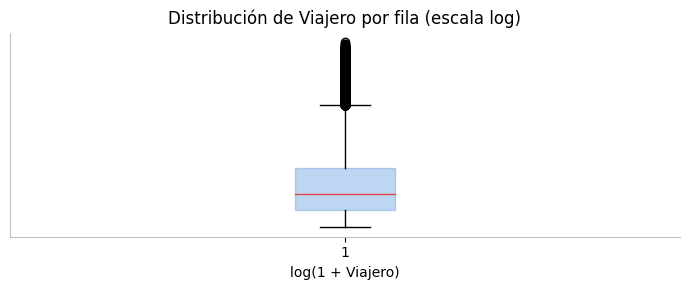

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(np.log1p(df['Viajero']), patch_artist=True,
           boxprops=dict(facecolor=COLORS[0], alpha=0.3, edgecolor=COLORS[0]),
           medianprops=dict(color=COLORS[7]))
ax.set_xlabel('log(1 + Viajero)')
ax.set_yticks([])
ax.set_title('Distribución de Viajero por fila (escala log)')
fig.tight_layout()

La variable está fuertemente sesgada a la derecha (media ≈ 325, mediana = 7, máximo > 92,000), lo cual tiene sentido: cada fila es una combinación específica de país/frontera/vía/tipo de viajero, y la mayoría de esas combinaciones son pequeñas (ej. un país lejano cruzando por una frontera terrestre) mientras que unas pocas concentran volúmenes enormes (ej. El Salvador por Valle Nuevo). No se tratan como error, es la naturaleza de los datos desagregados. Al agregar por mes para construir las series de tiempo este problema desaparece.

## 3. Estadísticas descriptivas

In [13]:
df['Viajero'].describe()

count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

In [14]:
df.groupby('Tipo de Viajero')['Viajero'].agg(['count', 'sum', 'mean']).sort_values('sum', ascending=False)

,count,sum,mean
Tipo de Viajero,,,
Turista,117912,3.764273e+07,319.244255
Excursionista,19730,9.069184e+06,459.664690
Viajero,23190,4.471622e+06,192.825451
Cruceristas,204,1.104402e+06,5413.735294


Turista es, por mucho, la categoría dominante (~118 mil filas, más de 33 millones de viajeros acumulados). Como indica el enunciado, `Viajero` (el tipo, no la columna numérica) cae fuerte desde 2023 porque cambió la forma de clasificar a los viajeros no turísticos de alta frecuencia, así que para comparaciones en todo el rango conviene usar Turista + Excursionista.

## 4. Comportamiento temporal

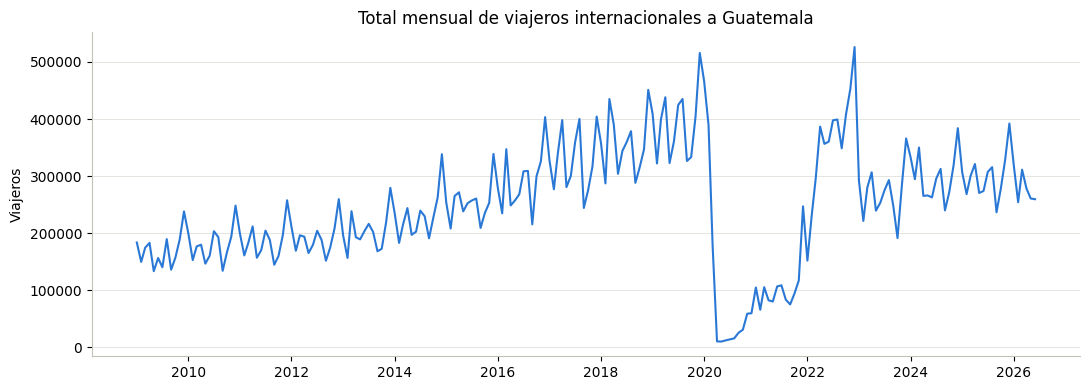

In [15]:
df['fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
serie_total = df.groupby('fecha')['Viajero'].sum().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie_total.index, serie_total.values, color=COLORS[0], linewidth=1.5)
ax.set_title('Total mensual de viajeros internacionales a Guatemala')
ax.set_ylabel('Viajeros')
fig.tight_layout()

Se ve una tendencia creciente entre 2009 y 2019, estacionalidad marcada dentro de cada año (picos en diciembre, valles a mitad de año), el desplome casi total durante 2020-2021 por la pandemia, y una recuperación que para 2022 ya supera los niveles pre-pandemia. De 2023 en adelante el nivel se ve más bajo e irregular que 2019, coherente con el cambio de metodología de clasificación mencionado en el enunciado.

## 5. Países con mayor cantidad de viajeros

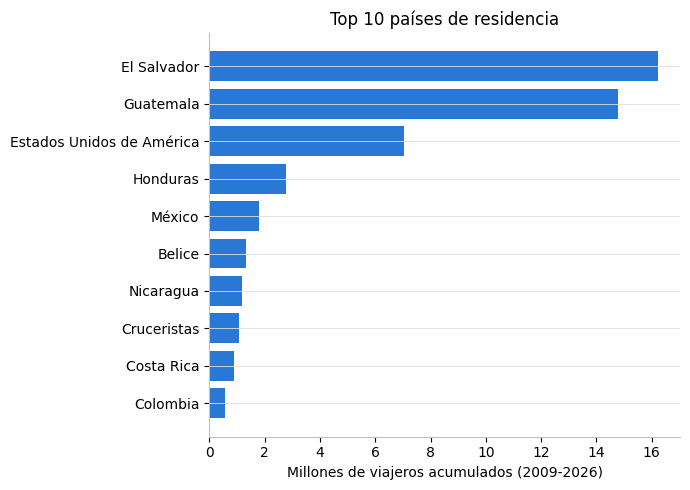

In [16]:
top_paises = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_paises.index[::-1], top_paises.values[::-1] / 1e6, color=COLORS[0])
ax.set_xlabel('Millones de viajeros acumulados (2009-2026)')
ax.set_title('Top 10 países de residencia')
fig.tight_layout()

In [17]:
top_paises

País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

Los países centroamericanos y Estados Unidos dominan el ranking, lo cual es esperable dado que la mayor parte del ingreso es terrestre y de la región. El top 3 (Guatemala, Estados Unidos, México) va a ser la base para la serie de "países de residencia" si el equipo elige esa categoría.

## 6. Regiones con mayor cantidad de viajeros

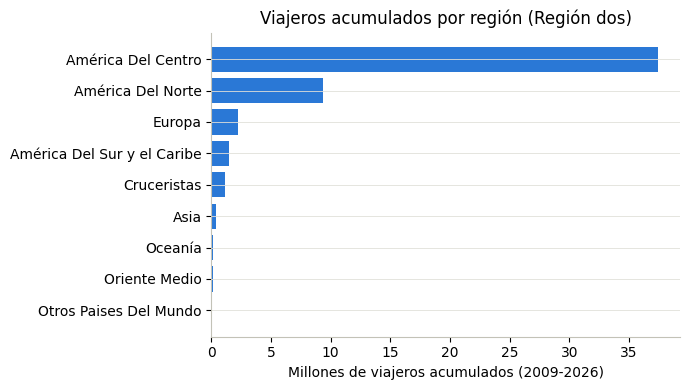

In [18]:
top_regiones = df.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_regiones.index[::-1], top_regiones.values[::-1] / 1e6, color=COLORS[0])
ax.set_xlabel('Millones de viajeros acumulados (2009-2026)')
ax.set_title('Viajeros acumulados por región (Región dos)')
fig.tight_layout()

In [19]:
top_regiones

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.105223e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Otros Paises Del Mundo         2.511115e+04
Name: Viajero, dtype: float64

América del Centro concentra la mayoría del ingreso, seguida de América del Norte y luego Europa. Las tres primeras (América del Centro, América del Norte, Europa) serían la base de la serie por región geográfica.

## 7. Vías de ingreso y fronteras más utilizadas

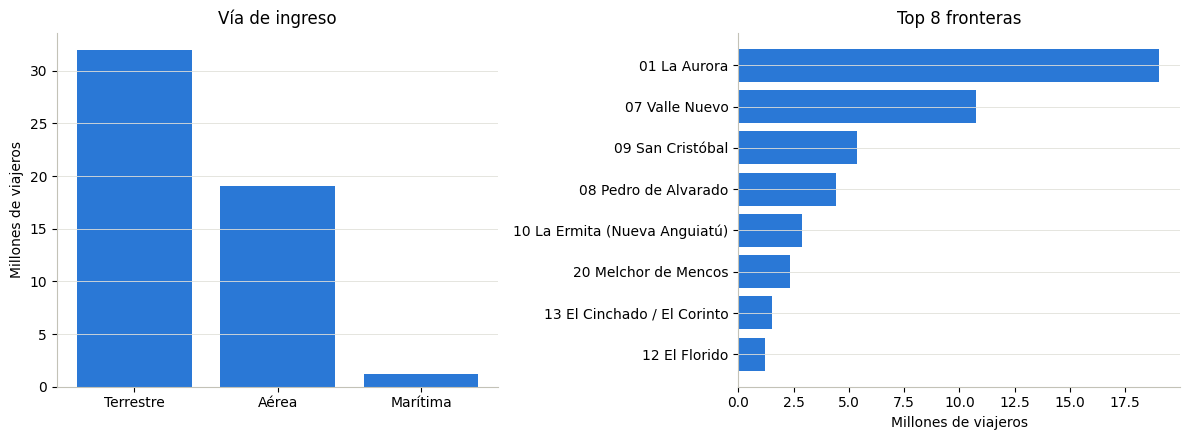

In [20]:
via = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
top_fronteras = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(via.index, via.values / 1e6, color=COLORS[0])
axes[0].set_ylabel('Millones de viajeros')
axes[0].set_title('Vía de ingreso')

axes[1].barh(top_fronteras.index[::-1], top_fronteras.values[::-1] / 1e6, color=COLORS[0])
axes[1].set_xlabel('Millones de viajeros')
axes[1].set_title('Top 8 fronteras')
fig.tight_layout()

La vía terrestre concentra la mayor parte del ingreso (~32 millones acumulados), muy por encima de la aérea (~19 millones) y la marítima (~1.2 millones). Entre las fronteras, La Aurora (vía aérea) y Valle Nuevo (frontera con El Salvador) son las más usadas por mucho margen.

## 8. Efecto de la pandemia

caída en abril 2020 vs abril 2019: 97.7%


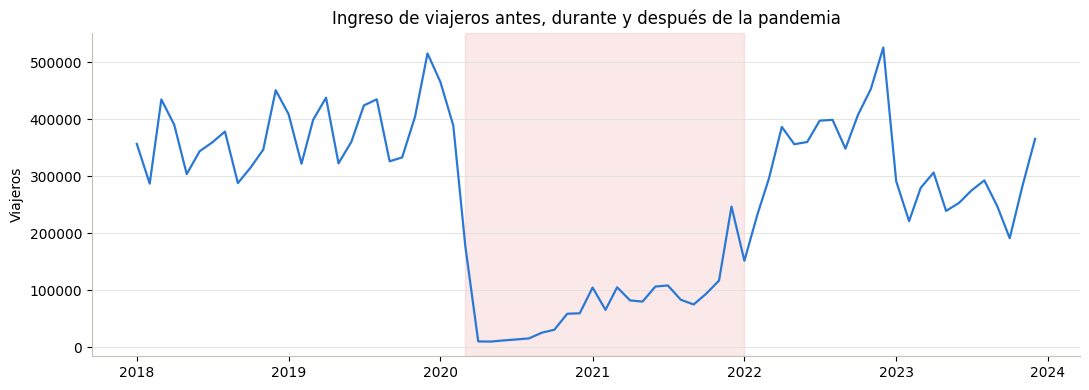

In [21]:
pandemia = serie_total.loc['2018-01-01':'2023-12-01']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pandemia.index, pandemia.values, color=COLORS[0], linewidth=1.6)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color=COLORS[7], alpha=0.12)
ax.set_title('Ingreso de viajeros antes, durante y después de la pandemia')
ax.set_ylabel('Viajeros')
fig.tight_layout()

caida = 1 - serie_total['2020-04-01'] / serie_total['2019-04-01']
print(f'caída en abril 2020 vs abril 2019: {caida:.1%}')

Abril 2020 tuvo casi 98% menos viajeros que abril 2019. La recuperación empieza a notarse a partir de mediados de 2021 y para 2022 el total mensual ya vuelve a niveles comparables (o mayores) a los de 2019. Esta zona (marzo 2020 - diciembre 2021, sombreada) va a ser importante mencionarla al analizar cada serie individual, porque rompe cualquier patrón de tendencia/estacionalidad que se venía dando antes.

## 9. Nota sobre el cambio de metodología 2022-2023

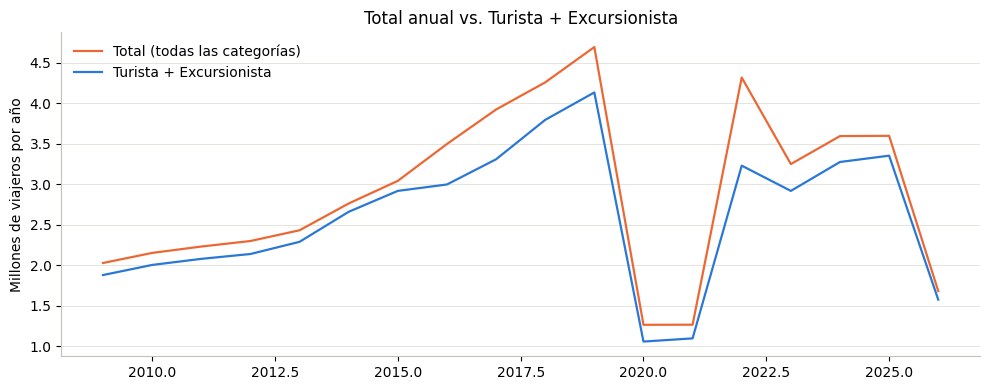

In [22]:
anual_tipo = df.groupby(['Año', 'Tipo de Viajero'])['Viajero'].sum().unstack(fill_value=0)
anual_tipo['Turista + Excursionista'] = anual_tipo['Turista'] + anual_tipo['Excursionista']
anual_tipo['Total'] = anual_tipo[['Turista', 'Excursionista', 'Viajero', 'Cruceristas']].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(anual_tipo.index, anual_tipo['Total'] / 1e6, color=COLORS[1], linewidth=1.6, label='Total (todas las categorías)')
ax.plot(anual_tipo.index, anual_tipo['Turista + Excursionista'] / 1e6, color=COLORS[0], linewidth=1.6, label='Turista + Excursionista')
ax.set_ylabel('Millones de viajeros por año')
ax.set_title('Total anual vs. Turista + Excursionista')
ax.legend(frameon=False)
fig.tight_layout()

Se confirma lo que dice el enunciado: el total "de todas las categorías" muestra una caída fuerte en 2023 que no es real, es un efecto del cambio de clasificación (los viajeros de comercio fronterizo y tránsito dejaron de contarse en "Viajero"). La curva de Turista + Excursionista es mucho más consistente en todo el período y es la que se debería usar para comparar años entre sí.

## 10. División en entrenamiento y prueba

Como es una serie de tiempo, el split no puede ser aleatorio (rompería el orden temporal y filtraría información del futuro al set de entrenamiento). Se corta cronológicamente: el 70% de los meses más antiguos van a entrenamiento y el 30% más reciente a prueba.

In [23]:
meses = np.array(sorted(df['fecha'].unique()))
corte = meses[int(len(meses) * 0.7)]
print('mes de corte:', pd.Timestamp(corte).strftime('%Y-%m'))
print(f'{int(len(meses)*0.7)} de {len(meses)} meses en train ({int(len(meses)*0.7)/len(meses):.0%})')

mes de corte: 2021-04
147 de 210 meses en train (70%)


In [24]:
train = df[df['fecha'] < corte].drop(columns='fecha')
test = df[df['fecha'] >= corte].drop(columns='fecha')

print('train:', train.shape, '->', train['Año'].min(), '-', 'hasta', pd.Timestamp(corte) - pd.DateOffset(months=1))
print('test:', test.shape, '->', pd.Timestamp(corte).strftime('%Y-%m'), 'en adelante')
print(f'proporción de filas en train: {len(train)/len(df):.1%}')

train: (131442, 13) -> 2009 - hasta 2021-03-01 00:00:00
test: (29594, 13) -> 2021-04 en adelante
proporción de filas en train: 81.6%


La proporción de filas queda en ~82/18 en vez de 70/30 porque los años recientes tienen menos combinaciones país/frontera reportadas por fila (sobre todo 2020-2021 y post cambio de metodología), pero en términos de meses -que es lo que importa para las series de tiempo- el split sí es 70/30. train.csv es lo que el resto del equipo debe usar para construir y modelar las series; test.csv se deja aparte para evaluar las predicciones al final.

In [25]:
train.to_csv('train.csv', index=False, encoding='utf-8-sig')
test.to_csv('test.csv', index=False, encoding='utf-8-sig')